In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# 1. Dataset Load karna
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
print("Dataset Head:\n", df.head())

Dataset Head:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


In [15]:
# 2. Features aur Target ko alag karna
# 'X' mein saare inputs honge aur 'y' mein price
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [17]:
# 3. Feature Scaling (Sabse important step)
# Isse saare features ek scale par aa jate hain
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
# 4. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [21]:
# 5. Multiple Models ko Train aur Compare karna
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MSE": round(mse, 4),
        "R2 Score": round(r2, 4)
    })

# Comparison Table dikhana
comparison_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(comparison_df)


Model Performance Comparison:
               Model     MSE  R2 Score
0  Linear Regression  0.5559    0.5758
1   Ridge Regression  0.5559    0.5758
2      Decision Tree  0.5245    0.5997


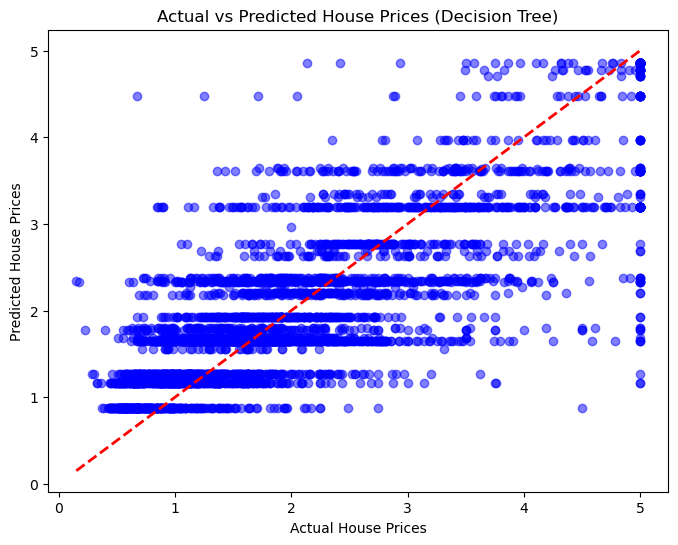

In [23]:
# 6. Visualization (Actual vs Predicted)
# Hum Decision Tree (ya best model) ka result plot karenge
best_model = DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train, y_train)
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Decision Tree)")
plt.show()

In [25]:
import joblib

# Maan lo Decision Tree best perform kar raha hai
joblib.dump(best_model, 'housing_model_v1.pkl')
print("Model saved successfully as housing_model_v1.pkl")

Model saved successfully as housing_model_v1.pkl
